<a href="https://colab.research.google.com/github/eternitvy/ML_26/blob/main/JS06/JS06_Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# import library
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.svm import SVC

In [2]:
# buat sebuah fungsi untuk menampilkan fitting data

def plot_svc_decision_function(model, ax=None, plot_support=True):

    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # buat grid untuk evaluasi model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot batas dan margin
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

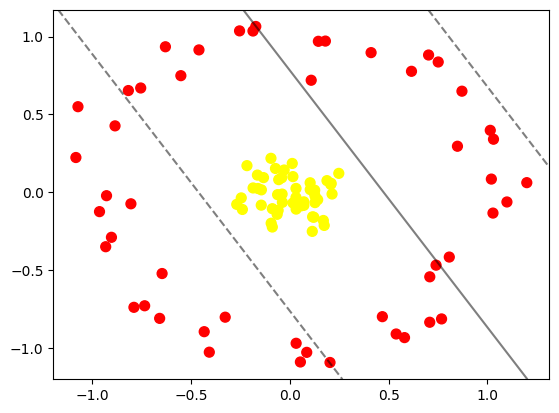

In [3]:
# contoh data tidak terpisah secara linier
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

clf = SVC(kernel='linear').fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf, plot_support=False);

In [4]:
r = np.exp(-(X**2).sum(1))

In [5]:
from mpl_toolkits import mplot3d
from ipywidgets import interact, fixed

def plot_3D(elev=30, azim=30, X=X, y=y):
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('r')

interact(plot_3D, elev=[-90, 45, 30, 20 , 10], azip=(-180, 180),
         X=fixed(X), y=fixed(y))

interactive(children=(Dropdown(description='elev', index=2, options=(-90, 45, 30, 20, 10), value=30), IntSlide…

<function __main__.plot_3D(elev=30, azim=30, X=array([[ 1.08066145e-01,  7.19745125e-01],
       [ 5.75385206e-02, -8.70678681e-02],
       [-2.87850615e-02,  1.42970298e-01],
       [-1.44842006e-01, -8.29319784e-02],
       [ 3.10235196e-02, -3.35534368e-02],
       [-5.51740401e-01,  7.49095820e-01],
       [-9.63558553e-01, -1.24511836e-01],
       [ 1.21435750e-01, -1.60718315e-01],
       [ 4.68284241e-01, -7.99438691e-01],
       [-6.46747566e-01, -5.22243624e-01],
       [ 1.02007191e+00,  8.46249326e-02],
       [-5.92915658e-02, -1.16554148e-01],
       [-1.86049293e-01,  2.76202838e-02],
       [ 3.17777032e-02, -1.08268698e-01],
       [-8.04621192e-01, -7.42434243e-02],
       [ 7.08727829e-02, -8.40088890e-02],
       [ 1.02709662e-01,  6.09541947e-02],
       [-2.46022511e-01, -3.63209196e-02],
       [ 1.79916209e-01,  9.71385695e-01],
       [ 1.69620339e-01, -1.81444371e-01],
       [ 2.07144022e-01,  5.03074586e-02],
       [-9.56600459e-02,  2.18110910e-01],
       [-9.28016125e-01, -2.20553926e-02],
       [-2.54627399e-01,  1.03689488e+00],
       [ 3.18393203e-02, -9.70390477e-01],
       [ 2.47791075e-01,  1.21444248e-01],
       [ 1.01458066e+00,  3.97906296e-01],
       [ 1.03106549e-01,  1.73198282e-02],
       [-3.27293461e-01, -8.02776713e-01],
       [ 3.98465739e-02, -8.44670416e-02],
       [ 7.07305805e-02, -6.16601760e-02],
       [ 1.87944218e-01,  7.46423296e-02],
       [-2.17145894e-01,  1.71035445e-01],
       [ 1.27305234e-01, -6.65124065e-02],
       [ 7.51040230e-01,  8.37032460e-01],
       [ 8.71179816e-01,  6.49372914e-01],
       [ 1.55030301e-02,  1.00406127e-01],
       [-8.86561945e-02, -1.05595538e-01],
       [-5.63768461e-02,  8.10856244e-02],
       [ 2.13652630e-01, -1.12455826e-02],
       [-4.33584653e-01, -8.95938269e-01],
       [-1.07261139e+00,  5.49777966e-01],
       [-2.68843409e-01, -7.77886385e-02],
       [ 8.54609724e-02, -1.02870164e+00],
       [ 1.09891473e+00, -6.24107770e-02],
       [ 8.07111376e-01, -4.16407959e-01],
       [-4.07790688e-01, -1.02764096e+00],
       [-7.35012051e-01, -7.29423173e-01],
       [-6.59076023e-01, -8.10438729e-01],
       [ 7.08406972e-01, -5.43397126e-01],
       [ 7.68019854e-01, -8.13930109e-01],
       [ 1.19949983e+00,  6.16899947e-02],
       [-9.03150890e-01, -2.89454326e-01],
       [-1.44157909e-01,  1.54764337e-02],
       [ 1.25676019e-01,  1.31219364e-02],
       [-1.72471532e-01,  1.06520753e+00],
       [-7.54956429e-01,  6.69966000e-01],
       [-2.40327435e-01, -1.10532296e-01],
       [ 1.27464116e-01, -2.37009962e-02],
       [-3.92195587e-02, -1.17343436e-02],
       [ 3.10885722e-02,  2.44836186e-02],
       [-4.11078053e-02,  9.33093934e-02],
       [ 5.33951521e-02, -1.09061491e+00],
       [ 5.38195757e-01, -9.10784843e-01],
       [-1.08311279e+00,  2.23255645e-01],
       [-8.17505739e-01,  6.53496764e-01],
       [ 1.02822785e+00, -1.33825608e-01],
       [ 1.03082910e+00,  3.40739721e-01],
       [-7.89331237e-01, -7.39353476e-01],
       [ 2.09102139e-01,  5.73182149e-02],
       [-1.60996618e-01,  2.40251621e-02],
       [-3.78767973e-02, -6.47218044e-02],
       [ 1.74000529e-01, -2.13154551e-01],
       [ 1.20959892e-02,  1.85089320e-01],
       [ 2.03303566e-01, -1.09380364e+00],
       [ 7.08132592e-01, -8.35320079e-01],
       [-6.29925820e-01,  9.34817799e-01],
       [ 1.22858572e-01, -9.60218307e-04],
       [ 4.11240245e-01,  8.97226083e-01],
       [-4.60121207e-01,  9.14671875e-01],
       [-9.32208979e-01, -3.50033424e-01],
       [ 1.13490093e-01, -2.51489629e-01],
       [-6.42400353e-02, -1.41695151e-01],
       [-9.45942977e-02, -1.99048138e-01],
       [-1.33351551e-01,  9.40311957e-02],
       [ 1.40771382e-01, -4.77842903e-02],
       [-7.28174916e-02,  1.52790654e-01],
       [ 6.15768188e-01,  7.77137593e-01],
       [ 1.15155733e-01, -1.57838840e-01],
       [ 5.80454076e-01, -9.34015903e-01],
       [ 8.48443266e-01,  2.95627431e-01],
       [-1.86637245e-01,  1.03598129e+00

In [6]:
clf = SVC(kernel='rbf', C=1E6)
clf.fit(X, y)

SVC(C=1000000.0)

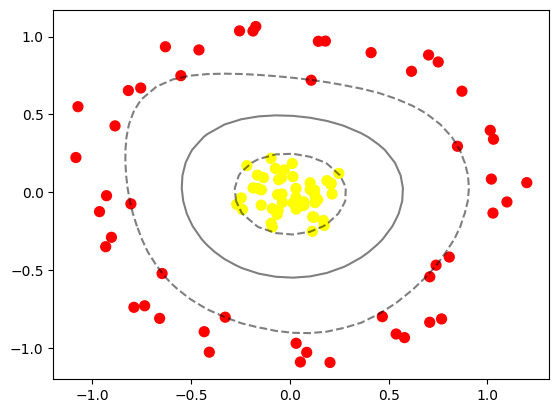

In [7]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=300, lw=1, facecolors='none')